# Data visualization

### Channels

```json
"modality": { 
	 "0": "FLAIR",
	 "1": "T1w", 
	 "2": "t1gd",
	 "3": "T2w"
 }
```
` "0": "FLAIR"` is best at showing lesions

`"1": "T1w"` is best at showing clean anatomy

`"2": "t1gd"` is best at enhancing tumors

`"3": "T2w"` is best at showing edemas

### Labels
```json
"labels": { 
    "0": "background", 
    "1": "edema",
    "2": "non-enhancing tumor",
    "3": "enhancing tumour"
}
```
`"0": "background"` corresponds to nonabnormal regions

`"1": "edema"` corresponds to regions with fluid buildup

`"2": "non-enhancing tumor"` corresponds to tumors that do not take up contrast during imaging

`"3": "enhancing tumour"` corresponds to tumors that do take up contrast during imaging

In [7]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# Define paths
dataset = 'Task01_BrainTumour'
sample_name = 'BRATS_001.nii.gz'

sample_path = f'{dataset}/imagesTr/{sample_name}'
label_path = f'{dataset}/labelsTr/{sample_name}'

# Load the files
sample = nib.load(sample_path)
label = nib.load(label_path)

# Access numerical data from sample and label
sample_data = sample.get_fdata()
label_data = label.get_fdata()

print(f'Sample shape:  {sample_data.shape}')
print(f'Label shape: {label_data.shape}')

Sample shape:  (240, 240, 155, 4)
Label shape: (240, 240, 155)


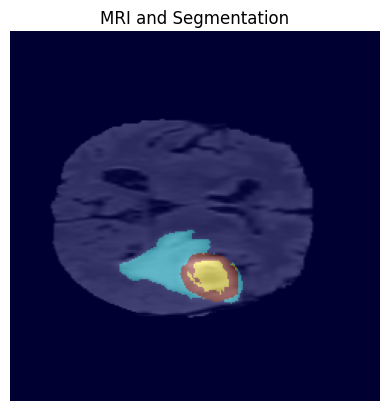

In [ ]:
# Visualize the middle slice
slice_index = sample_data.shape[2]//2 
channel = 0

# Extract the slice
# Will probably apply normalization for U-Net training
visual_label = label_data[:, :, slice_index]
visual_sample = sample_data[:, :, slice_index, 0]

# Plot
plt.imshow(visual_sample, cmap='gray')
plt.imshow(visual_label, cmap='jet', alpha=0.4)
plt.title("MRI and Segmentation")
plt.axis('off')
plt.show()

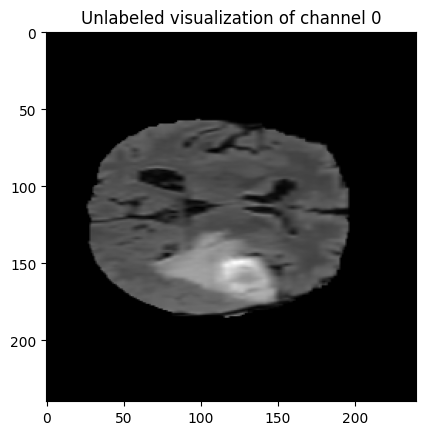

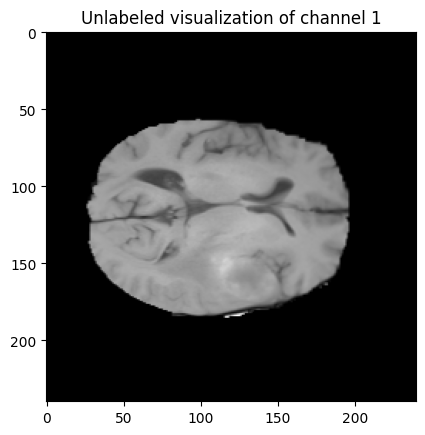

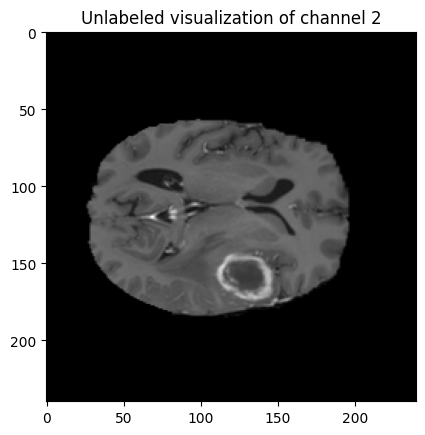

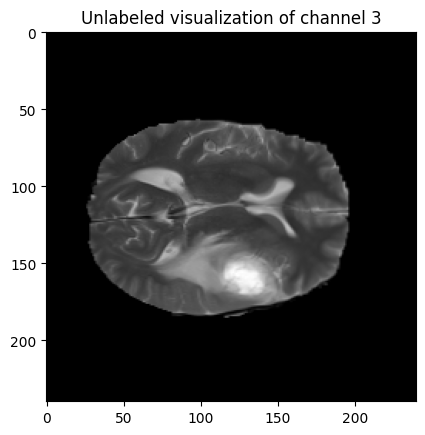

In [32]:
# Visualize all 4 channels
for channel in range(4):
    plt.imshow(sample_data[:, :, slice_index, channel], cmap='gray')
    plt.title(f'Unlabeled visualization of channel {channel}')
    plt.show()
